# UC4 — Brute Force Detection: XGBoost Training & Evaluation

**Goal:** Train a supervised XGBoost binary classifier on CICIDS2017 network
flow data to distinguish benign traffic from brute-force attacks
(FTP-Patator, SSH-Patator).

### Relationship to UC2

UC2 and UC4 share the same feature set (`uc2_feature_cols.json`) and the same
model type (XGBoost), but target mechanistically different attack families:

| | UC2 (DDoS) | UC4 (Brute Force) |
|---|---|---|
| **Attack** | Volumetric flooding | Credential-based repeated auth |
| **Source** | Friday afternoon | Tuesday |
| **Key features** | High byte/packet rates, sustained flows | Short connections, RST flags, targeted ports |

In the Detection microservice, both models run on the same flow feature
vector — one flow in, two independent predictions out.

### Inputs (from `uc4_cicids2017_data_prep.ipynb`)

| File | Description |
|------|-------------|
| `uc4_train.csv` | Monday benign + first 70% of Tuesday |
| `uc4_test.csv` | Last 30% of Tuesday (temporal holdout) |

Feature columns are loaded from `uc2_feature_cols.json` (feature parity).

### Pipeline

1. Load prepared CSVs and feature list
2. Exploratory sanity checks
3. Train XGBoost with class-imbalance handling (`scale_pos_weight`)
4. Probability threshold optimization via PR curve
5. Evaluation: confusion matrix, classification report, ROC-AUC, PR-AUC
6. Feature importance analysis
7. False positive / false negative profiling
8. Cross-UC evaluation (UC2 model on Brute Force, UC4 model on DDoS)
9. Model persistence (joblib artifact bundle)
10. Inference helper for Detection microservice

### Design Constraints

- **No circular labeling** — labels from CIC ground truth annotations.
- **Temporal split** — train/test boundary preserves time ordering.
- **Feature parity with UC2** — identical feature columns.

In [26]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print(f'XGBoost version: {xgb.__version__}')
print('Libraries loaded.')

XGBoost version: 3.2.0
Libraries loaded.


## 1. Configuration

In [27]:
# ── Paths ──
DATA_DIR     = './data/uc4_prepared/'
FEAT_DIR = './data/'
MODEL_DIR    = './models/'
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_CSV    = os.path.join(DATA_DIR, 'uc4_train.csv')
TEST_CSV     = os.path.join(DATA_DIR, 'uc4_test.csv')
META_JSON    = os.path.join(DATA_DIR, 'uc4_metadata.json')
FEAT_JSON    = os.path.join(FEAT_DIR, 'feature_cols.json')
ARTIFACT_OUT = os.path.join(MODEL_DIR, 'brute_force_xgboost.pkl')

# UC2 model for cross-evaluation
UC2_ARTIFACT = os.path.join('../ddos/models/', 'ddos_xgboost.pkl')

# ── Random seed ──
SEED = 42

print(f'Train CSV:      {TRAIN_CSV}')
print(f'Test CSV:       {TEST_CSV}')
print(f'Feature list:   {FEAT_JSON}')
print(f'Artifact output: {ARTIFACT_OUT}')

Train CSV:      ./data/uc4_prepared/uc4_train.csv
Test CSV:       ./data/uc4_prepared/uc4_test.csv
Feature list:   ./data/feature_cols.json
Artifact output: ./models/brute_force_xgboost.pkl


## 2. Load Prepared Data

In [28]:
with open(FEAT_JSON) as f:
    feature_cols = json.load(f)

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print(f'Feature columns: {len(feature_cols)}')
print(f'Train: {len(df_train):>10,} rows')
print(f'Test:  {len(df_test):>10,} rows')

# Verify all feature columns exist
for c in feature_cols:
    assert c in df_train.columns, f'Missing in train: {c}'
    assert c in df_test.columns,  f'Missing in test: {c}'
print('\nAll feature columns present in both splits.')

Feature columns: 45
Train:    841,133 rows
Test:     134,694 rows

All feature columns present in both splits.


## 3. Sanity Checks

In [29]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    n = len(df)
    n_atk = (df['label'] == 1).sum()
    n_ben = (df['label'] == 0).sum()
    feat = df[feature_cols]
    n_nan = feat.isna().sum().sum()
    n_inf = np.isinf(feat.select_dtypes(include=np.number)).sum().sum()

    print(f'── {name} ──')
    print(f'  Rows:    {n:>10,}')
    print(f'  Benign:  {n_ben:>10,}  ({100 * n_ben / n:.2f}%)')
    print(f'  Attack:  {n_atk:>10,}  ({100 * n_atk / n:.2f}%)')
    print(f'  NaN: {n_nan:,}  Inf: {n_inf:,}')
    if n_atk > 0:
        print(f'  Imbalance ratio: 1:{n_ben // n_atk}')
    print()

assert df_train[feature_cols].isna().sum().sum() == 0, 'NaN in train features!'
assert df_test[feature_cols].isna().sum().sum() == 0, 'NaN in test features!'
print('No NaN/Inf in features.')

── Train ──
  Rows:       841,133
  Benign:     830,102  (98.69%)
  Attack:      11,031  (1.31%)
  NaN: 0  Inf: 0
  Imbalance ratio: 1:75

── Test ──
  Rows:       134,694
  Benign:     131,890  (97.92%)
  Attack:       2,804  (2.08%)
  NaN: 0  Inf: 0
  Imbalance ratio: 1:47

No NaN/Inf in features.


## 4. Prepare Feature Matrices

In [30]:
X_train = df_train[feature_cols].values
y_train = df_train['label'].values

X_test = df_test[feature_cols].values
y_test = df_test['label'].values

# Standardize (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train_scaled.shape}')
print(f'X_test:  {X_test_scaled.shape}')
print(f'y_train distribution: {np.bincount(y_train)}')
print(f'y_test distribution:  {np.bincount(y_test)}')

X_train: (841133, 45)
X_test:  (134694, 45)
y_train distribution: [830102  11031]
y_test distribution:  [131890   2804]


## 5. Train XGBoost

`scale_pos_weight` compensates for class imbalance (same approach as UC2).
Computed as ratio of benign to attack samples in training set.

In [31]:
n_benign = (y_train == 0).sum()
n_attack = (y_train == 1).sum()
spw = n_benign / max(n_attack, 1)

print(f'scale_pos_weight: {spw:.2f}  (benign: {n_benign:,}, attack: {n_attack:,})')

# Chronological validation holdout from the training set
# (df_train is already in temporal order: Monday benign + first 70% of Tuesday)
val_frac = 0.15
val_start = int(len(X_train_scaled) * (1 - val_frac))
X_tr, X_val = X_train_scaled[:val_start], X_train_scaled[val_start:]
y_tr, y_val = y_train[:val_start],        y_train[val_start:]

print(f'Train:      {len(X_tr):>10,} rows  (benign={np.sum(y_tr==0):,}, attack={np.sum(y_tr==1):,})')
print(f'Validation: {len(X_val):>10,} rows  (benign={np.sum(y_val==0):,}, attack={np.sum(y_val==1):,})')

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=20
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=50
)

print('\nTraining complete.')

scale_pos_weight: 75.25  (benign: 830,102, attack: 11,031)
Train:         714,963 rows  (benign=709,066, attack=5,897)
Validation:    126,170 rows  (benign=121,036, attack=5,134)
[0]	validation_0-logloss:0.43234	validation_1-logloss:0.44763
[42]	validation_0-logloss:0.00524	validation_1-logloss:0.16424

Training complete.


## 6. Training Curves

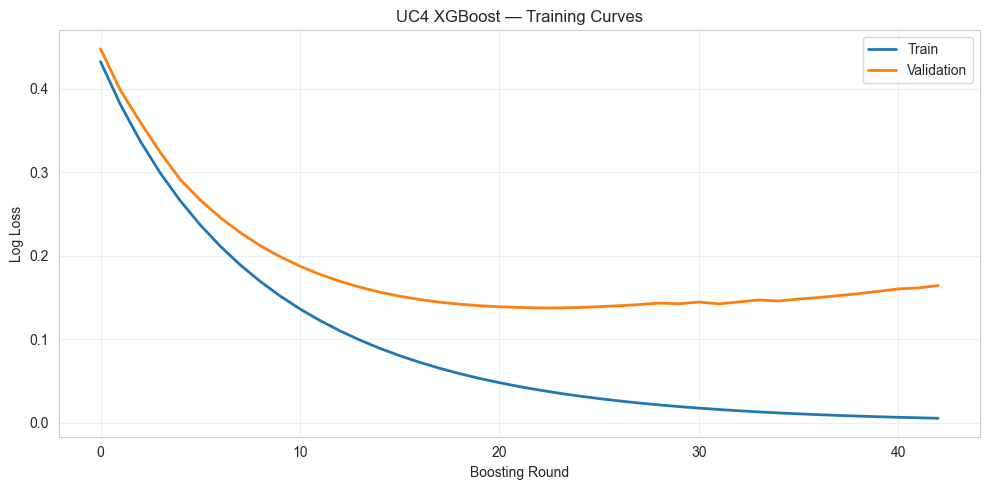

Final train loss: 0.005244
Final validation loss:  0.164245
⚠ Notable gap between train and validation loss — potential overfitting.


In [32]:
results = model.evals_result()
train_loss = results['validation_0']['logloss']
val_loss  = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, label='Train', linewidth=2)
ax.plot(val_loss, label='Validation', linewidth=2)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('UC4 XGBoost — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final train loss: {train_loss[-1]:.6f}')
print(f'Final validation loss:  {val_loss[-1]:.6f}')

# Check for overfitting
if val_loss[-1] > train_loss[-1] * 1.5:
    print('⚠ Notable gap between train and validation loss — potential overfitting.')
else:
    print('Train/test loss gap is acceptable.')

## 7. Evaluation at Default Threshold (0.5)

In [33]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print('── Default Threshold (0.5) ──\n')
print(classification_report(y_test, y_pred_default,
                            target_names=['Benign', 'Brute Force'], digits=4))

fp = ((y_test == 0) & (y_pred_default == 1)).sum()
fn = ((y_test == 1) & (y_pred_default == 0)).sum()
fpr_val = fp / max((y_test == 0).sum(), 1)
print(f'FPR: {fpr_val:.4f}  |  FP: {fp:,}  |  FN: {fn:,}')

── Default Threshold (0.5) ──

              precision    recall  f1-score   support

      Benign     0.9792    1.0000    0.9895    131890
 Brute Force     0.0000    0.0000    0.0000      2804

    accuracy                         0.9792    134694
   macro avg     0.4896    0.5000    0.4947    134694
weighted avg     0.9588    0.9792    0.9689    134694

FPR: 0.0000  |  FP: 0  |  FN: 2,804


## 8. Threshold Optimization via PR Curve

Sweep probability thresholds to find the F1-optimal operating point.
Also identify a FPR-targeted threshold for conservative deployment.

In [34]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)

# F1 at each threshold
f1_arr = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_arr)
best_threshold = thresholds_pr[best_f1_idx]

print(f'F1-optimal threshold: {best_threshold:.6f}')
print(f'  F1:        {f1_arr[best_f1_idx]:.4f}')
print(f'  Precision: {precisions[best_f1_idx]:.4f}')
print(f'  Recall:    {recalls[best_f1_idx]:.4f}')

# FPR-targeted threshold
TARGET_FPR = 0.01
fpr_thresholds = np.linspace(0, 1, 2000)
for t in fpr_thresholds:
    preds_t = (y_proba >= t).astype(int)
    fpr_t = ((y_test == 0) & (preds_t == 1)).sum() / max((y_test == 0).sum(), 1)
    if fpr_t <= TARGET_FPR:
        fpr_tuned_threshold = t
        break
else:
    fpr_tuned_threshold = 0.5
    print(f'⚠ Could not find threshold with FPR ≤ {TARGET_FPR}')

preds_fpr = (y_proba >= fpr_tuned_threshold).astype(int)
fpr_actual = ((y_test == 0) & (preds_fpr == 1)).sum() / max((y_test == 0).sum(), 1)
f1_fpr = f1_score(y_test, preds_fpr, zero_division=0)

print(f'\nFPR-tuned threshold: {fpr_tuned_threshold:.6f}')
print(f'  FPR:    {fpr_actual:.4f}  (target: {TARGET_FPR})')
print(f'  F1:     {f1_fpr:.4f}')
print(f'  Recall: {recall_score(y_test, preds_fpr, zero_division=0):.4f}')

F1-optimal threshold: 0.039541
  F1:        0.8858
  Precision: 0.7995
  Recall:    0.9929

FPR-tuned threshold: 0.038519
  FPR:    0.0079  (target: 0.01)
  F1:     0.8399
  Recall: 0.9929


## 9. PR & ROC Curves

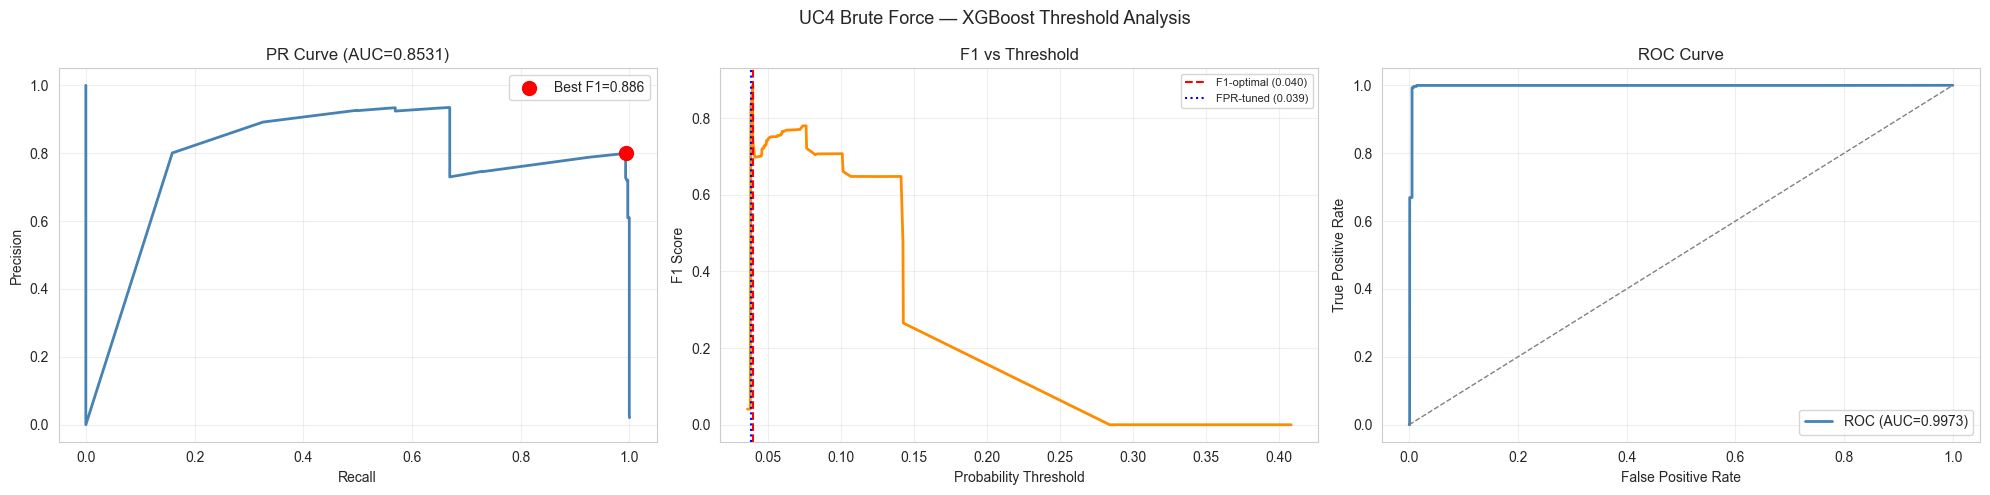

PR-AUC:  0.8531
ROC-AUC: 0.9973


In [35]:
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# PR curve
axes[0].plot(recalls, precisions, lw=2, color='steelblue')
axes[0].scatter(recalls[best_f1_idx], precisions[best_f1_idx],
                color='red', s=100, zorder=5,
                label=f'Best F1={f1_arr[best_f1_idx]:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve (AUC={pr_auc:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds_pr, f1_arr, lw=2, color='darkorange')
axes[1].axvline(best_threshold, color='red', ls='--',
                label=f'F1-optimal ({best_threshold:.3f})')
axes[1].axvline(fpr_tuned_threshold, color='blue', ls=':',
                label=f'FPR-tuned ({fpr_tuned_threshold:.3f})')
axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Threshold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ROC curve
axes[2].plot(fpr_arr, tpr_arr, lw=2, color='steelblue',
             label=f'ROC (AUC={roc_auc:.4f})')
axes[2].plot([0, 1], [0, 1], ls='--', color='gray', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('UC4 Brute Force — XGBoost Threshold Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'PR-AUC:  {pr_auc:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')

## 10. Select Operating Threshold

Choose between F1-optimal (balanced precision/recall) and FPR-tuned
(conservative, low false alarm rate). The Detection microservice uses
the selected threshold for production predictions.

In [36]:
# Select F1-optimal as primary (same strategy as UC2)
threshold = best_threshold

print(f'Selected operating threshold: {threshold:.6f}  (F1-optimal)')
print(f'  F1-optimal:  {best_threshold:.6f}')
print(f'  FPR-tuned:   {fpr_tuned_threshold:.6f}  (reference)')

Selected operating threshold: 0.039541  (F1-optimal)
  F1-optimal:  0.039541
  FPR-tuned:   0.038519  (reference)


## 11. Final Evaluation (Selected Threshold)

── Threshold: 0.039541 ──

              precision    recall  f1-score   support

      Benign     0.9998    0.9947    0.9973    131890
 Brute Force     0.7995    0.9929    0.8858      2804

    accuracy                         0.9947    134694
   macro avg     0.8997    0.9938    0.9415    134694
weighted avg     0.9957    0.9947    0.9950    134694

FPR: 0.0053  |  FP: 698  |  FN: 20


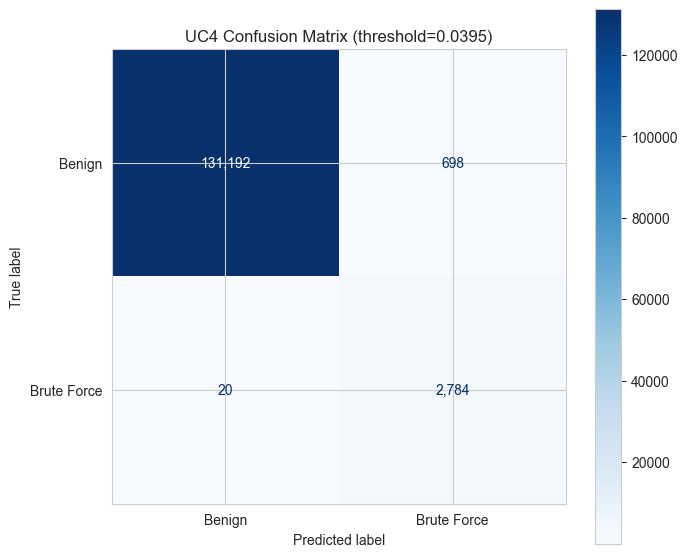

In [37]:
y_pred = (y_proba >= threshold).astype(int)

print(f'── Threshold: {threshold:.6f} ──\n')
print(classification_report(y_test, y_pred,
                            target_names=['Benign', 'Brute Force'], digits=4))

fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()
fpr_val = fp / max((y_test == 0).sum(), 1)
print(f'FPR: {fpr_val:.4f}  |  FP: {fp:,}  |  FN: {fn:,}')

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Benign', 'Brute Force'],
    cmap='Blues', ax=ax, values_format=',')
ax.set_title(f'UC4 Confusion Matrix (threshold={threshold:.4f})')
plt.tight_layout()
plt.show()

## 12. FPR-Tuned Evaluation (Reference)

In [38]:
y_pred_fpr = (y_proba >= fpr_tuned_threshold).astype(int)

print(f'── FPR-Tuned Threshold: {fpr_tuned_threshold:.6f} ──\n')
print(classification_report(y_test, y_pred_fpr,
                            target_names=['Benign', 'Brute Force'], digits=4))

fp_fpr = ((y_test == 0) & (y_pred_fpr == 1)).sum()
fn_fpr = ((y_test == 1) & (y_pred_fpr == 0)).sum()
fpr_fpr = fp_fpr / max((y_test == 0).sum(), 1)
print(f'FPR: {fpr_fpr:.4f}  |  FP: {fp_fpr:,}  |  FN: {fn_fpr:,}')

── FPR-Tuned Threshold: 0.038519 ──

              precision    recall  f1-score   support

      Benign     0.9998    0.9921    0.9960    131890
 Brute Force     0.7278    0.9929    0.8399      2804

    accuracy                         0.9921    134694
   macro avg     0.8638    0.9925    0.9180    134694
weighted avg     0.9942    0.9921    0.9927    134694

FPR: 0.0079  |  FP: 1,041  |  FN: 20


## 13. Threshold Comparison Table

In [39]:
eval_thresholds = {
    'Default (0.5)':   0.5,
    'F1-optimal':      best_threshold,
    'FPR-tuned':       fpr_tuned_threshold,
}

print(f'{"Threshold":20s}  {"Value":>10s}  {"Precision":>10s}  {"Recall":>10s}  '
      f'{"F1":>10s}  {"FPR":>10s}  {"FP":>8s}  {"FN":>8s}')
print('-' * 95)

for name, t in eval_thresholds.items():
    preds = (y_proba >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    fp_t = ((y_test == 0) & (preds == 1)).sum()
    fn_t = ((y_test == 1) & (preds == 0)).sum()
    fpr_t = fp_t / max((y_test == 0).sum(), 1)
    marker = '  ◄' if t == threshold else ''
    print(f'{name:20s}  {t:>10.6f}  {p:>10.4f}  {r:>10.4f}  '
          f'{f:>10.4f}  {fpr_t:>10.4f}  {fp_t:>8,}  {fn_t:>8,}{marker}')

Threshold                  Value   Precision      Recall          F1         FPR        FP        FN
-----------------------------------------------------------------------------------------------
Default (0.5)           0.500000      0.0000      0.0000      0.0000      0.0000         0     2,804
F1-optimal              0.039541      0.7995      0.9929      0.8858      0.0053       698        20  ◄
FPR-tuned               0.038519      0.7278      0.9929      0.8399      0.0079     1,041        20


## 14. Feature Importance

Top features for distinguishing brute-force from benign traffic.
Compared qualitatively with UC2 to confirm the two models learn
different decision boundaries.

── Top 15 Features ──
    0.7612  Destination Port
    0.1429  Init_Win_bytes_backward
    0.0280  Flow Bytes/s
    0.0170  Source Port
    0.0071  Fwd PSH Flags
    0.0070  min_seg_size_forward
    0.0062  Bwd Packets/s
    0.0059  Fwd IAT Min
    0.0043  Fwd Packet Length Mean
    0.0034  Packet Length Std
    0.0018  Bwd Packet Length Std
    0.0018  Flow Packets/s
    0.0017  Bwd Header Length
    0.0015  PSH Flag Count
    0.0015  Bwd IAT Max


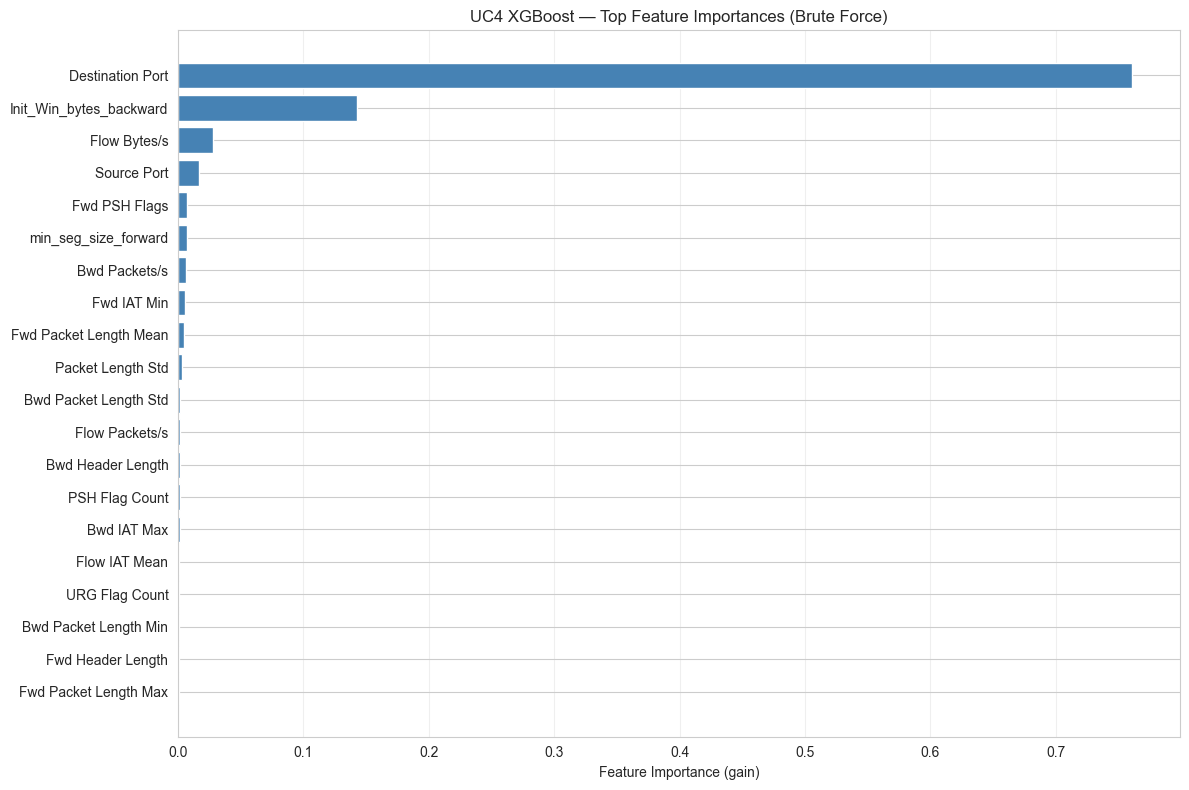

In [40]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances,
}).sort_values('importance', ascending=False)

print('── Top 15 Features ──')
for i, row in feat_imp.head(15).iterrows():
    print(f'  {row["importance"]:>8.4f}  {row["feature"]}')

fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(feat_imp))
top = feat_imp.head(top_n)
ax.barh(range(top_n), top['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('UC4 XGBoost — Top Feature Importances (Brute Force)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 15. Score Distribution

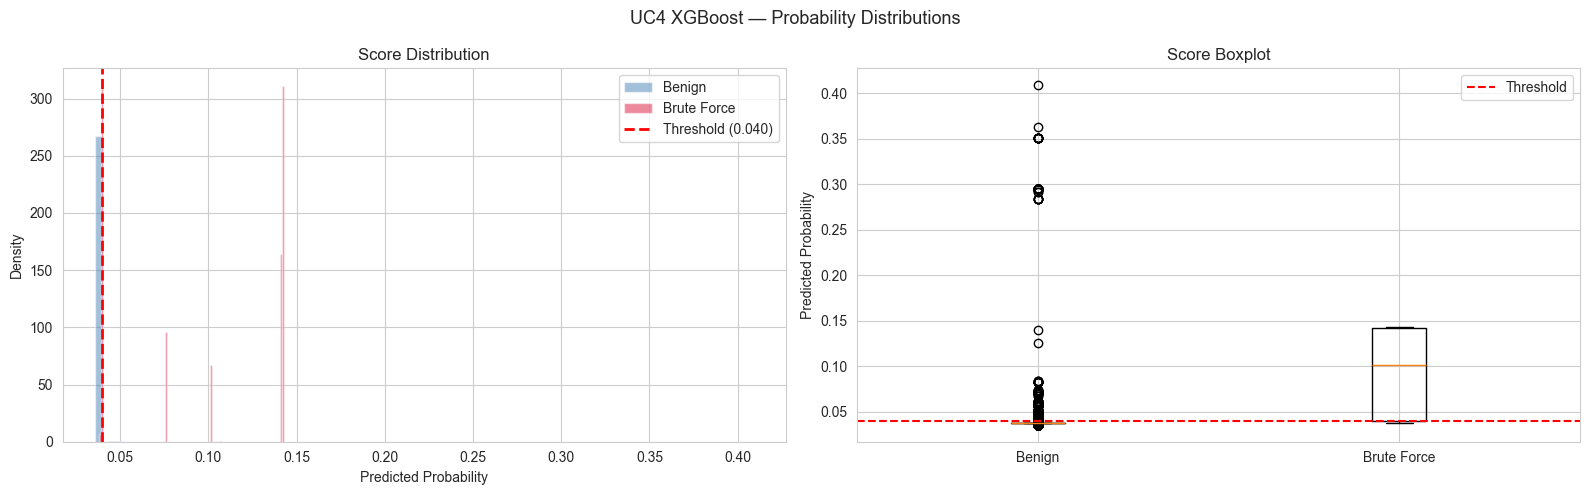

Benign median prob:  0.037900
Attack median prob:  0.101433
Separation (medians): 0.063533


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(y_proba[y_test == 0], bins=100, alpha=0.5, density=True,
        label='Benign', color='steelblue')
ax.hist(y_proba[y_test == 1], bins=100, alpha=0.5, density=True,
        label='Brute Force', color='crimson')
ax.axvline(threshold, color='red', ls='--', lw=2,
           label=f'Threshold ({threshold:.3f})')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution')
ax.legend()

# Boxplot
ax = axes[1]
ax.boxplot([y_proba[y_test == 0], y_proba[y_test == 1]],
           labels=['Benign', 'Brute Force'])
ax.axhline(threshold, color='red', ls='--', lw=1.5, label='Threshold')
ax.set_ylabel('Predicted Probability')
ax.set_title('Score Boxplot')
ax.legend()

plt.suptitle('UC4 XGBoost — Probability Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# Separation quality
ben_median = np.median(y_proba[y_test == 0])
atk_median = np.median(y_proba[y_test == 1])
print(f'Benign median prob:  {ben_median:.6f}')
print(f'Attack median prob:  {atk_median:.6f}')
print(f'Separation (medians): {abs(atk_median - ben_median):.6f}')

## 16. False Positive Analysis

Profile benign flows that were incorrectly flagged as brute-force.
Identifies which features cause false alarms.

In [42]:
fp_mask = (y_test == 0) & (y_pred == 1)
n_fp = fp_mask.sum()
print(f'False positives: {n_fp:,} / {(y_test == 0).sum():,} benign flows')

if n_fp > 0 and n_fp < len(df_test):
    # Compare FP feature means vs all benign
    fp_feats  = df_test.loc[fp_mask, feature_cols]
    ben_feats = df_test.loc[y_test == 0, feature_cols]
    atk_feats = df_test.loc[y_test == 1, feature_cols]

    ben_mean = ben_feats.mean()
    ben_std  = ben_feats.std().replace(0, 1e-9)
    fp_z = ((fp_feats.mean() - ben_mean) / ben_std).abs().sort_values(ascending=False)

    print(f'\nTop features driving FPs (z-score vs benign baseline):')
    for feat, z in fp_z.head(10).items():
        fp_val = fp_feats[feat].mean()
        ben_val = ben_mean[feat]
        atk_val = atk_feats[feat].mean()
        print(f'  {feat:40s}  z={z:>6.2f}  '
              f'(FP={fp_val:>12.2f}, benign={ben_val:>12.2f}, attack={atk_val:>12.2f})')

    # FP probability distribution
    fp_probs = y_proba[fp_mask]
    print(f'\nFP probability range: [{fp_probs.min():.4f}, {fp_probs.max():.4f}]')
    print(f'FP probability median: {np.median(fp_probs):.4f}')
    print(f'FPs near threshold (prob < threshold+0.1): '
          f'{(fp_probs < threshold + 0.1).sum()} / {n_fp}')
elif n_fp == 0:
    print('No false positives — perfect precision on benign class.')

False positives: 698 / 131,890 benign flows

Top features driving FPs (z-score vs benign baseline):
  URG Flag Count                            z=  1.41  (FP=        0.58, benign=        0.12, attack=        0.00)
  Protocol                                  z=  0.92  (FP=        6.05, benign=       11.08, attack=        6.00)
  ACK Flag Count                            z=  0.83  (FP=        0.66, benign=        0.29, attack=        0.50)
  Min Packet Length                         z=  0.82  (FP=        0.09, benign=       20.53, attack=        0.00)
  Bwd Packet Length Min                     z=  0.71  (FP=        0.58, benign=       51.09, attack=        0.00)
  Fwd Packet Length Min                     z=  0.56  (FP=        0.14, benign=       21.14, attack=        0.00)
  Init_Win_bytes_forward                    z=  0.48  (FP=    14629.96, benign=     7114.19, attack=    14693.84)
  min_seg_size_forward                      z=  0.37  (FP=       28.49, benign=       26.13, attack=  

## 17. False Negative Analysis

Profile attack flows that the model missed. Understanding these
reveals the limits of per-flow supervised detection.

In [43]:
fn_mask = (y_test == 1) & (y_pred == 0)
n_fn = fn_mask.sum()
print(f'False negatives: {n_fn:,} / {(y_test == 1).sum():,} attack flows')

if n_fn > 0 and n_fn < len(df_test):
    fn_feats  = df_test.loc[fn_mask, feature_cols]
    atk_feats = df_test.loc[y_test == 1, feature_cols]
    ben_feats = df_test.loc[y_test == 0, feature_cols]

    atk_mean = atk_feats.mean()
    atk_std  = atk_feats.std().replace(0, 1e-9)

    # How similar are FN flows to benign?
    ben_mean = ben_feats.mean()
    fn_mean  = fn_feats.mean()

    # Distance from FN to benign vs FN to attack centroids
    fn_to_ben = np.sqrt(((fn_mean - ben_mean) ** 2).sum())
    fn_to_atk = np.sqrt(((fn_mean - atk_mean) ** 2).sum())

    print(f'\nFN centroid distance to benign:  {fn_to_ben:.2f}')
    print(f'FN centroid distance to attack:  {fn_to_atk:.2f}')
    if fn_to_ben < fn_to_atk:
        print('→ FN flows are closer to benign — they look like benign traffic.')
    else:
        print('→ FN flows are closer to attack — borderline cases near threshold.')

    # FN probability distribution
    fn_probs = y_proba[fn_mask]
    print(f'\nFN probability range:  [{fn_probs.min():.4f}, {fn_probs.max():.4f}]')
    print(f'FN probability median: {np.median(fn_probs):.4f}')
    print(f'FNs near threshold (prob > threshold-0.1): '
          f'{(fn_probs > threshold - 0.1).sum()} / {n_fn}')
elif n_fn == 0:
    print('No false negatives — perfect recall on attack class.')

False negatives: 20 / 2,804 attack flows

FN centroid distance to benign:  9293508.12
FN centroid distance to attack:  2116310.00
→ FN flows are closer to attack — borderline cases near threshold.

FN probability range:  [0.0379, 0.0384]
FN probability median: 0.0384
FNs near threshold (prob > threshold-0.1): 20 / 20


## 18. Cross-UC Evaluation

Test whether UC2's DDoS model catches brute-force traffic and vice versa.
This validates that the two models learn genuinely different decision
boundaries, justifying separate models in the Detection service.

**If `uc2_xgboost.joblib` is not available**, this section is skipped
gracefully — it can be run later after UC2 training is complete.

In [44]:
if os.path.exists(UC2_ARTIFACT):
    print('── Cross-UC: UC2 (DDoS) predictions on UC4 test set (Brute Force) ──\n')
    uc2_art    = joblib.load(UC2_ARTIFACT)
    uc2_scaler = uc2_art['scaler']
    uc2_model  = uc2_art['model']
    uc2_thresh = uc2_art['threshold']

    uc2_proba = uc2_model.predict_proba(uc2_scaler.transform(X_test))[:, 1]
    uc2_pred  = (uc2_proba >= uc2_thresh).astype(int)

    # Per-model recall on BF
    attack_mask = (y_test == 1)
    uc2_catches = (uc2_pred == 1) & attack_mask
    uc4_catches = (y_pred  == 1) & attack_mask

    n_atk     = attack_mask.sum()
    n_uc2     = uc2_catches.sum()
    n_uc4     = uc4_catches.sum()
    n_both    = (uc2_catches & uc4_catches).sum()
    n_uc2only = (uc2_catches & ~uc4_catches).sum()
    n_uc4only = (~uc2_catches & uc4_catches).sum()
    n_missed  = (attack_mask & ~uc2_catches & ~uc4_catches).sum()

    print(f'Total BF flows in test:       {n_atk:,}')
    print(f'UC2 catches:                  {n_uc2:,}   (recall {n_uc2/max(n_atk,1):.4f})')
    print(f'UC4 catches:                  {n_uc4:,}   (recall {n_uc4/max(n_atk,1):.4f})')
    print(f'Union (either catches):       {(uc2_catches|uc4_catches).sum():,}')
    print(f'  both models agree:          {n_both:,}')
    print(f'  UC2 only (UC4 misses):      {n_uc2only:,}')
    print(f'  UC4 only (UC2 misses):      {n_uc4only:,}   ← UC4 marginal value')
    print(f'  neither catches:            {n_missed:,}')

    # FP comparison on benign
    benign_mask = (y_test == 0)
    fp_uc2 = ((uc2_pred == 1) & benign_mask).sum()
    fp_uc4 = ((y_pred  == 1) & benign_mask).sum()
    print(f'\nBenign FPs  — UC2: {fp_uc2:,}   UC4: {fp_uc4:,}')
else:
    print(f'UC2 artifact not found at {UC2_ARTIFACT} — skipping marginal-catch analysis.')

── Cross-UC: UC2 (DDoS) predictions on UC4 test set (Brute Force) ──

Total BF flows in test:       2,804
UC2 catches:                  0   (recall 0.0000)
UC4 catches:                  2,784   (recall 0.9929)
Union (either catches):       2,784
  both models agree:          0
  UC2 only (UC4 misses):      0
  UC4 only (UC2 misses):      2,784   ← UC4 marginal value
  neither catches:            20

Benign FPs  — UC2: 0   UC4: 698


In [45]:
UC2_TEST_CSV = os.path.join('../ddos/data/', 'uc2_test.csv')

if os.path.exists(UC2_ARTIFACT) and os.path.exists(UC2_TEST_CSV):
    print('── Cross-UC: UC4 (BF model) on UC2 test set (DDoS) ──\n')
    df_uc2_test = pd.read_csv(UC2_TEST_CSV)

    X_uc2_test = scaler.transform(df_uc2_test[feature_cols].values)
    uc4_on_ddos_proba = model.predict_proba(X_uc2_test)[:, 1]
    uc4_on_ddos_pred  = (uc4_on_ddos_proba >= threshold).astype(int)
    y_uc2_test = df_uc2_test['label'].values

    print(classification_report(y_uc2_test, uc4_on_ddos_pred,
                                target_names=['Benign', 'DDoS'], digits=4))

    uc4_on_ddos_f1  = f1_score(y_uc2_test, uc4_on_ddos_pred, zero_division=0)
    uc4_on_ddos_rec = recall_score(y_uc2_test, uc4_on_ddos_pred, zero_division=0)

    print(f'UC4 (BF model) on DDoS data — Recall: {uc4_on_ddos_rec:.4f}, F1: {uc4_on_ddos_f1:.4f}')
    print()
    if uc4_on_ddos_rec < 0.5:
        print('→ UC4 does NOT generalize to DDoS — confirms different decision boundaries.')
    else:
        print('→ UC4 partially detects DDoS — some feature overlap between attack types.')
else:
    print('UC2 test data or artifact not available — skipping reverse cross-evaluation.')

── Cross-UC: UC4 (BF model) on UC2 test set (DDoS) ──

              precision    recall  f1-score   support

      Benign     0.7285    0.9979    0.8421     40804
        DDoS     0.9926    0.4353    0.6052     26880

    accuracy                         0.7745     67684
   macro avg     0.8605    0.7166    0.7237     67684
weighted avg     0.8334    0.7745    0.7481     67684

UC4 (BF model) on DDoS data — Recall: 0.4353, F1: 0.6052

→ UC4 does NOT generalize to DDoS — confirms different decision boundaries.


## 19. Per-Attack-Type Breakdown

Evaluate FTP-Patator and SSH-Patator separately to check whether the
model is equally effective on both brute-force variants.

**Note:** This requires the original `Label` column. If the test CSV
only has binary `label`, this cell uses `uc4_metadata.json` to
identify attack types — but the detailed per-type breakdown requires
loading the raw Tuesday CSV.

In [46]:
if 'attack_type' in df_test.columns:
    print('── Per-Attack-Type Metrics ──\n')
    for attack_label in ['FTP-Patator', 'SSH-Patator']:
        mask = df_test['attack_type'] == attack_label
        n_type = mask.sum()
        if n_type == 0:
            print(f'{attack_label:20s}  Not present in test set')
            continue
        type_pred = y_pred[mask]
        type_true = y_test[mask]
        rec = recall_score(type_true, type_pred, zero_division=0)
        prec = precision_score(type_true, type_pred, zero_division=0)
        f1 = f1_score(type_true, type_pred, zero_division=0)
        n_detected = type_pred.sum()
        print(f'{attack_label:20s}  {n_detected:>6,} / {n_type:>6,} detected  '
              f'(recall: {rec:.4f}, precision: {prec:.4f}, F1: {f1:.4f})')

    print(f'\n{"Overall":20s}  recall: {recall_score(y_test, y_pred, zero_division=0):.4f}')
else:
    print('No attack_type column in test CSV — run uc4_cicids2017_data_prep.ipynb')
    print('with attack_type included in export_cols.')
    print(f'Overall attack recall: {recall_score(y_test, y_pred, zero_division=0):.4f}')

── Per-Attack-Type Metrics ──

FTP-Patator            2,784 /  2,804 detected  (recall: 0.9929, precision: 1.0000, F1: 0.9964)
SSH-Patator           Not present in test set

Overall               recall: 0.9929


## 20. Model Persistence

Save as a single artifact bundle, matching UC2's format. The Detection
microservice loads both `uc2_xgboost.joblib` and `uc4_xgboost.joblib`
and runs both on every incoming flow.

In [47]:
artifact = {
    'model':          model,
    'scaler':         scaler,
    'threshold':      float(threshold),
    'fpr_threshold':  float(fpr_tuned_threshold),
    'feature_cols':   feature_cols,
    'params': {
        'n_estimators':     model.n_estimators,
        'max_depth':        model.max_depth,
        'learning_rate':    model.learning_rate,
        'scale_pos_weight': float(spw),
        'seed':             SEED,
        'target_fpr':       TARGET_FPR,
    },
    'metrics': {
        'f1':       float(f1_score(y_test, y_pred, zero_division=0)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall':   float(recall_score(y_test, y_pred, zero_division=0)),
        'roc_auc':  float(roc_auc),
        'pr_auc':   float(pr_auc),
        'fpr':      float(fpr_val),
    },
}

joblib.dump(artifact, ARTIFACT_OUT, compress=3)
size_mb = os.path.getsize(ARTIFACT_OUT) / (1024 * 1024)
print(f'Artifact saved: {ARTIFACT_OUT}  ({size_mb:.1f} MB)')
print(f'Contents: {list(artifact.keys())}')

Artifact saved: ./models/brute_force_xgboost.pkl  (0.0 MB)
Contents: ['model', 'scaler', 'threshold', 'fpr_threshold', 'feature_cols', 'params', 'metrics']


## 21. Artifact Verification

In [48]:
art = joblib.load(ARTIFACT_OUT)

# Re-score test set from artifact
X_verify = art['scaler'].transform(df_test[art['feature_cols']].values)
verify_proba = art['model'].predict_proba(X_verify)[:, 1]
verify_pred  = (verify_proba >= art['threshold']).astype(int)

assert np.allclose(verify_proba, y_proba, atol=1e-6), 'Probability mismatch!'
assert np.array_equal(verify_pred, y_pred), 'Prediction mismatch!'

print('Artifact verification passed.')
print(f'  Model:     {type(art["model"]).__name__}')
print(f'  Features:  {len(art["feature_cols"])}')
print(f'  Threshold: {art["threshold"]:.6f}')
print(f'  F1:        {art["metrics"]["f1"]:.4f}')
print(f'  ROC-AUC:   {art["metrics"]["roc_auc"]:.4f}')

Artifact verification passed.
  Model:     XGBClassifier
  Features:  45
  Threshold: 0.039541
  F1:        0.8858
  ROC-AUC:   0.9973


## 22. Inference Helper

Reusable function for the Detection microservice. The consumer runs
this alongside `predict_uc2()` on every flow from `log.normalized.flow`.

In [49]:
def predict_uc4(flow_features: dict, artifact_path: str = None) -> dict:
    """
    Run UC4 Brute Force inference on a single flow record.

    Parameters
    ----------
    flow_features : dict
        Feature values for one flow. Must contain all keys from feature_cols.
    artifact_path : str, optional
        Path to saved .joblib artifact.

    Returns
    -------
    dict with keys:
        'prediction': int (0=benign, 1=brute_force)
        'probability': float (attack probability)
        'threshold': float (operating threshold)
        'is_attack': bool
    """
    if artifact_path is None:
        artifact_path = ARTIFACT_OUT

    art = joblib.load(artifact_path)
    features = art['feature_cols']
    threshold_val = art['threshold']

    df = pd.DataFrame([flow_features])
    X = art['scaler'].transform(df[features].values)
    prob = art['model'].predict_proba(X)[0, 1]
    pred = int(prob >= threshold_val)

    return {
        'prediction': pred,
        'probability': float(prob),
        'threshold': threshold_val,
        'is_attack': bool(pred == 1),
    }


# Verification — predict on a test sample
sample_flow = df_test.iloc[0][feature_cols].to_dict()
result = predict_uc4(sample_flow)
print(f'Inference helper verified.')
print(f'Sample prediction: {result["prediction"]} '
      f'(prob={result["probability"]:.4f}, threshold={result["threshold"]:.4f})')

Inference helper verified.
Sample prediction: 0 (prob=0.0379, threshold=0.0395)


## 23. Summary

In [50]:
print('=' * 65)
print('UC4 BRUTE FORCE DETECTION — XGBOOST TRAINING SUMMARY')
print('=' * 65)
print(f'Dataset:        CICIDS2017 (Monday benign + Tuesday Brute Force)')
print(f'Model:          XGBoost (supervised binary classification)')
print(f'Features:       {len(feature_cols)} (shared with UC2)')
print(f'Training:       {len(df_train):>10,} rows')
print(f'Test:           {len(df_test):>10,} rows')
print()
print(f'── Thresholds ──')
print(f'F1-optimal:     {best_threshold:.6f}  (selected)')
print(f'FPR-tuned:      {fpr_tuned_threshold:.6f}  (reference, target FPR={TARGET_FPR})')
print()
print(f'── Metrics (F1-optimal threshold) ──')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print(f'F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'FPR:       {fpr_val:.4f}')
print()
print(f'── Artifact ──')
print(f'{ARTIFACT_OUT}')
print()
print(f'── Detection Service Integration ──')
print(f'Flow arrives → extract features → UC2 predict (DDoS?)')
print(f'                                → UC4 predict (Brute Force?)')
print(f'                                → publish both results to detection.results')

UC4 BRUTE FORCE DETECTION — XGBOOST TRAINING SUMMARY
Dataset:        CICIDS2017 (Monday benign + Tuesday Brute Force)
Model:          XGBoost (supervised binary classification)
Features:       45 (shared with UC2)
Training:          841,133 rows
Test:              134,694 rows

── Thresholds ──
F1-optimal:     0.039541  (selected)
FPR-tuned:      0.038519  (reference, target FPR=0.01)

── Metrics (F1-optimal threshold) ──
ROC-AUC:   0.9973
PR-AUC:    0.8531
F1:        0.8858
Precision: 0.7995
Recall:    0.9929
FPR:       0.0053

── Artifact ──
./models/brute_force_xgboost.pkl

── Detection Service Integration ──
Flow arrives → extract features → UC2 predict (DDoS?)
                                → UC4 predict (Brute Force?)
                                → publish both results to detection.results
